# SVM+PCA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from itertools import product

In [4]:
DATASET_PATH = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\processed\dataset.npz"
OUTPUT_DIR   = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results"

In [5]:
PCA_COMPONENTS = [150, 200, 300]
C_VALUES       = [1, 10, 100]
GAMMA_VALUES   = ['scale', 0.001]
 
RANDOM_SEED = 42

## Models and Functions

In [6]:
def load_data(path):
    """Load the preprocessed dataset from the .npz file."""
    print("Loading dataset...")
    data = np.load(path)
 
    X_train = np.concatenate([data['X_train'], data['X_val']])
    y_train = np.concatenate([data['y_train'], data['y_val']])
    X_test  = data['X_test']
    y_test  = data['y_test']
 
    print(f"  Training samples: {len(X_train)}")
    print(f"  Test samples:     {len(X_test)}\n")
 
    return X_train, X_test, y_train, y_test

In [7]:
def plot_confusion_matrix(y_true, y_pred, title, filename):
    """Plot and save a confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[f'PSA {i}' for i in range(1, 11)],
        yticklabels=[f'PSA {i}' for i in range(1, 11)]
    )
    plt.title(title)
    plt.ylabel('True Grade')
    plt.xlabel('Predicted Grade')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path)
    plt.close()  # close instead of show to save memory
    print(f"  Confusion matrix saved to: {save_path}")

In [8]:
def save_results_log(results, log_path):
    """Save all results so far to a text file after every fit."""
    with open(log_path, 'w', encoding='utf-8') as f:
        f.write(f"PCA + SVM Sequential Tuning Results\n{'='*60}\n\n")
        f.write(f"{'PCA':<8} {'C':<8} {'Gamma':<12} {'Exact Acc':<12} {'Within 1':<12}\n")
        f.write(f"{'-'*52}\n")
        for r in results:
            f.write(
                f"{r['pca']:<8} {r['C']:<8} {str(r['gamma']):<12} "
                f"{r['accuracy']*100:<12.1f} {r['within_one']*100:<12.1f}\n"
            )
 
        if results:
            best = max(results, key=lambda x: x['accuracy'])
            f.write(f"\n{'='*60}\n")
            f.write(f"Best so far:\n")
            f.write(f"  PCA={best['pca']}, C={best['C']}, gamma={best['gamma']}\n")
            f.write(f"  Exact accuracy:  {best['accuracy']*100:.1f}%\n")
            f.write(f"  Within 1 grade:  {best['within_one']*100:.1f}%\n")

In [9]:

def plot_final_comparison(results, filename):
    """Bar chart of all combinations sorted by accuracy."""
    results_sorted = sorted(results, key=lambda x: x['accuracy'], reverse=True)
    labels     = [f"PCA={r['pca']}\nC={r['C']}\ngamma={r['gamma']}" for r in results_sorted]
    accuracies = [r['accuracy'] * 100 for r in results_sorted]
    within_one = [r['within_one'] * 100 for r in results_sorted]
 
    x     = np.arange(len(labels))
    width = 0.35
 
    fig, ax = plt.subplots(figsize=(max(12, len(labels) * 1.5), 7))
    bars1 = ax.bar(x - width/2, accuracies, width, label='Exact Accuracy',  color='steelblue')
    bars2 = ax.bar(x + width/2, within_one,  width, label='Within 1 Grade', color='lightgreen')
 
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('PCA + SVM Parameter Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.legend()
    ax.set_ylim(0, 100)
 
    for bar in bars1:
        ax.annotate(f'{bar.get_height():.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7)
    for bar in bars2:
        ax.annotate(f'{bar.get_height():.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7)
 
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path)
    plt.show()
    print(f"Comparison chart saved to: {save_path}")

## Main Function

In [10]:
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    log_path = os.path.join(OUTPUT_DIR, 'svm_tuning_log.txt')
 
    X_train, X_test, y_train, y_test = load_data(DATASET_PATH)
 
    # Build list of all combinations
    combos = list(product(PCA_COMPONENTS, C_VALUES, GAMMA_VALUES))
    total  = len(combos)
    print(f"Total combinations to test: {total}")
    print(f"Results will be saved to:   {log_path}\n")
 
    results = []
 
    for i, (pca_n, c, gamma) in enumerate(combos, 1):
        print(f"{'='*50}")
        print(f"[{i}/{total}] PCA={pca_n}, C={c}, gamma={gamma}")
        print(f"{'='*50}")
 
        pipeline = Pipeline([
            ('pca', PCA(n_components=pca_n, random_state=RANDOM_SEED)),
            ('svm', SVC(kernel='rbf', C=c, gamma=gamma, random_state=RANDOM_SEED))
        ])
 
        pipeline.fit(X_train, y_train)
        preds      = pipeline.predict(X_test)
        accuracy   = accuracy_score(y_test, preds)
        within_one = np.mean(np.abs(y_test - preds) <= 1)
 
        print(f"  Exact accuracy:  {accuracy*100:.1f}%")
        print(f"  Within 1 grade:  {within_one*100:.1f}%\n")
 
        results.append({
            'pca':        pca_n,
            'C':          c,
            'gamma':      gamma,
            'accuracy':   accuracy,
            'within_one': within_one,
            'preds':      preds
        })
 
        # Save log after every single fit so nothing is lost if it crashes
        save_results_log(results, log_path)
 
    # Find and report the best combination
    best = max(results, key=lambda x: x['accuracy'])
    print(f"\n{'='*50}")
    print(f"All done! Best combination:")
    print(f"  PCA={best['pca']}, C={best['C']}, gamma={best['gamma']}")
    print(f"  Exact accuracy:  {best['accuracy']*100:.1f}%")
    print(f"  Within 1 grade:  {best['within_one']*100:.1f}%")
    print(f"{'='*50}")
 
    # Print full classification report for best model
    print(f"\nClassification Report for Best Model:")
    print(classification_report(
        y_test, best['preds'],
        target_names=[f'PSA {i}' for i in range(1, 11)],
        zero_division=0
    ))
 
    # Save confusion matrix for best model
    plot_confusion_matrix(
        y_test, best['preds'],
        f"Best PCA+SVM (PCA={best['pca']}, C={best['C']}, gamma={best['gamma']})",
        "svm_best_confusion.png"
    )  
 
    # Save comparison chart of all combinations
    plot_final_comparison(results, "svm_tuning_comparison.png")
    print(f"\nFull results log saved to: {log_path}")

Loading dataset...
  Training samples: 6487
  Test samples:     1145

Total combinations to test: 18
Results will be saved to:   C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\svm_tuning_log.txt

[1/18] PCA=150, C=1, gamma=scale
  Exact accuracy:  41.3%
  Within 1 grade:  70.8%

[2/18] PCA=150, C=1, gamma=0.001
  Exact accuracy:  50.7%
  Within 1 grade:  77.7%

[3/18] PCA=150, C=10, gamma=scale
  Exact accuracy:  52.9%
  Within 1 grade:  75.0%

[4/18] PCA=150, C=10, gamma=0.001
  Exact accuracy:  52.4%
  Within 1 grade:  79.0%

[5/18] PCA=150, C=100, gamma=scale
  Exact accuracy:  51.6%
  Within 1 grade:  75.1%

[6/18] PCA=150, C=100, gamma=0.001
  Exact accuracy:  52.4%
  Within 1 grade:  79.0%

[7/18] PCA=200, C=1, gamma=scale
  Exact accuracy:  41.7%
  Within 1 grade:  71.4%

[8/18] PCA=200, C=1, gamma=0.001
  Exact accuracy:  49.6%
  Within 1 grade:  77.2%

[9/18] PCA=200, C=10, gamma=scale
  Exact accuracy:  52.1%
  Within 1 grade:  75.0%

[

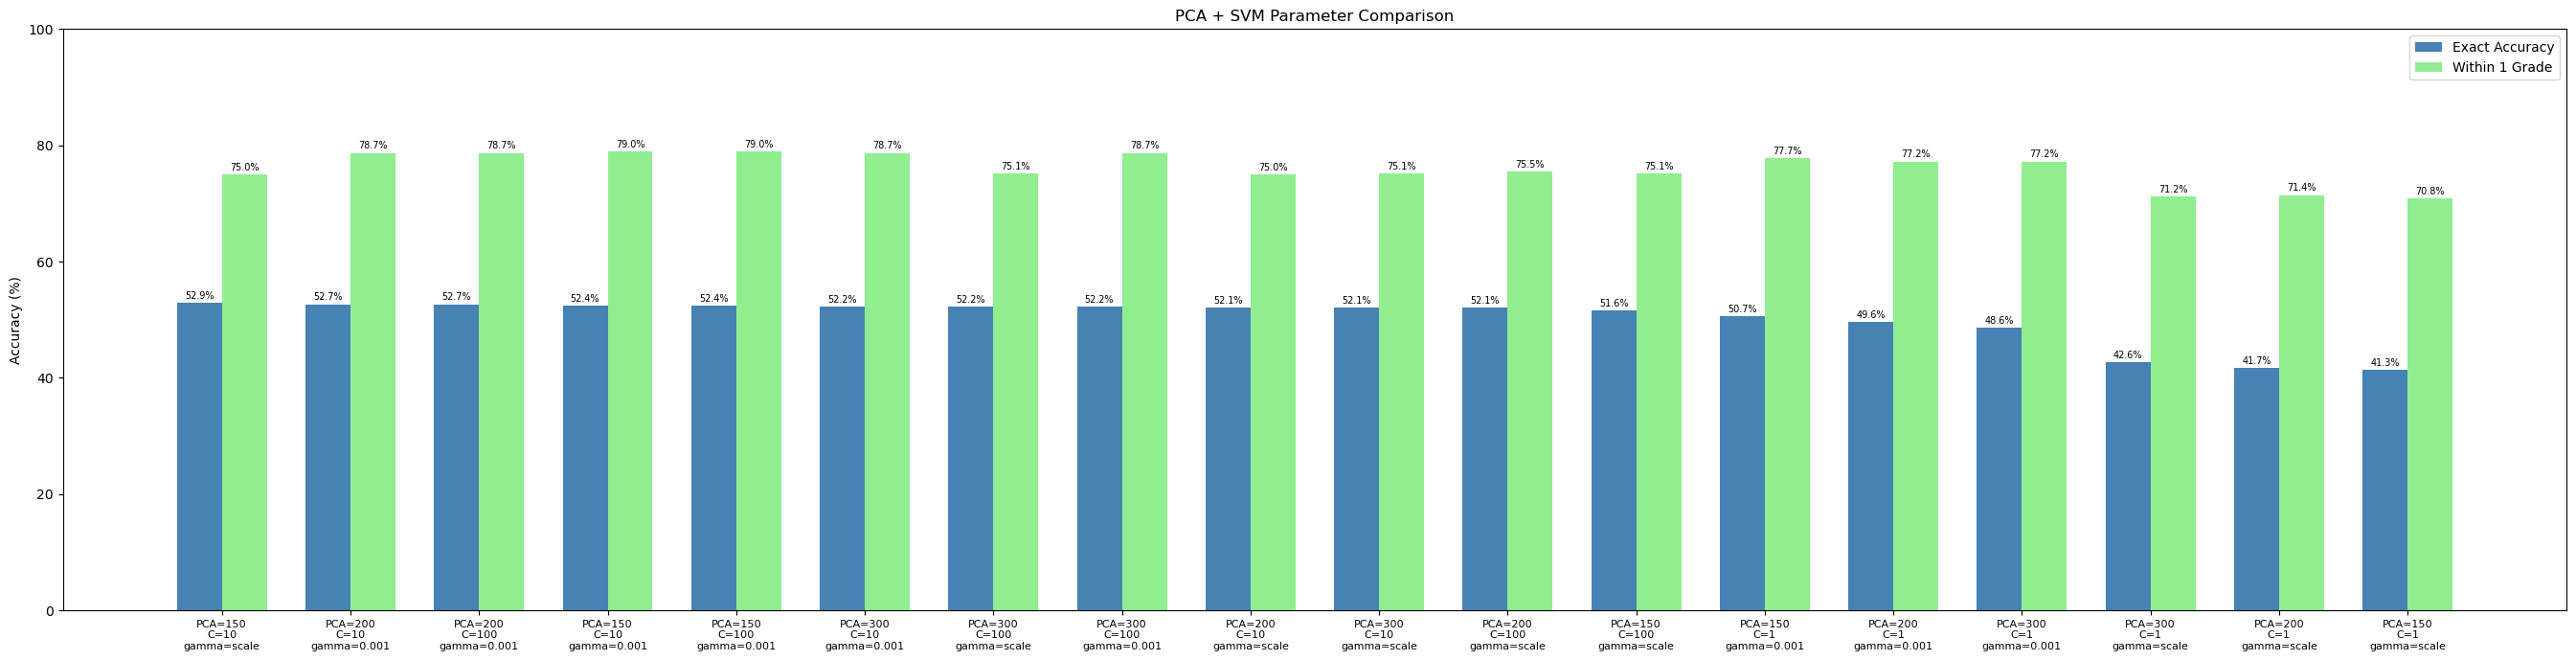

Comparison chart saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\svm_tuning_comparison.png

Full results log saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\svm_tuning_log.txt


In [11]:
main()